In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
%matplotlib inline

In [47]:
zernp = np.load("projection_segment1.pkl",allow_pickle=True)

In [48]:
zernp.keys(),zernp["basis"].keys()

(dict_keys(['basis', 'coefficients', 'opd', 'coefs_format']),
 dict_keys(['xy', 'n_radial_order', 'n_mode', 'modes', 'sids']))

In [49]:
xy = np.asarray(zernp["basis"]['xy'])
modes = np.asarray(zernp["basis"]["modes"]).reshape(zernp["basis"]["n_mode"],-1).T
opd = np.asarray(zernp["opd"])
c = np.asarray(zernp["coefficients"])

[]

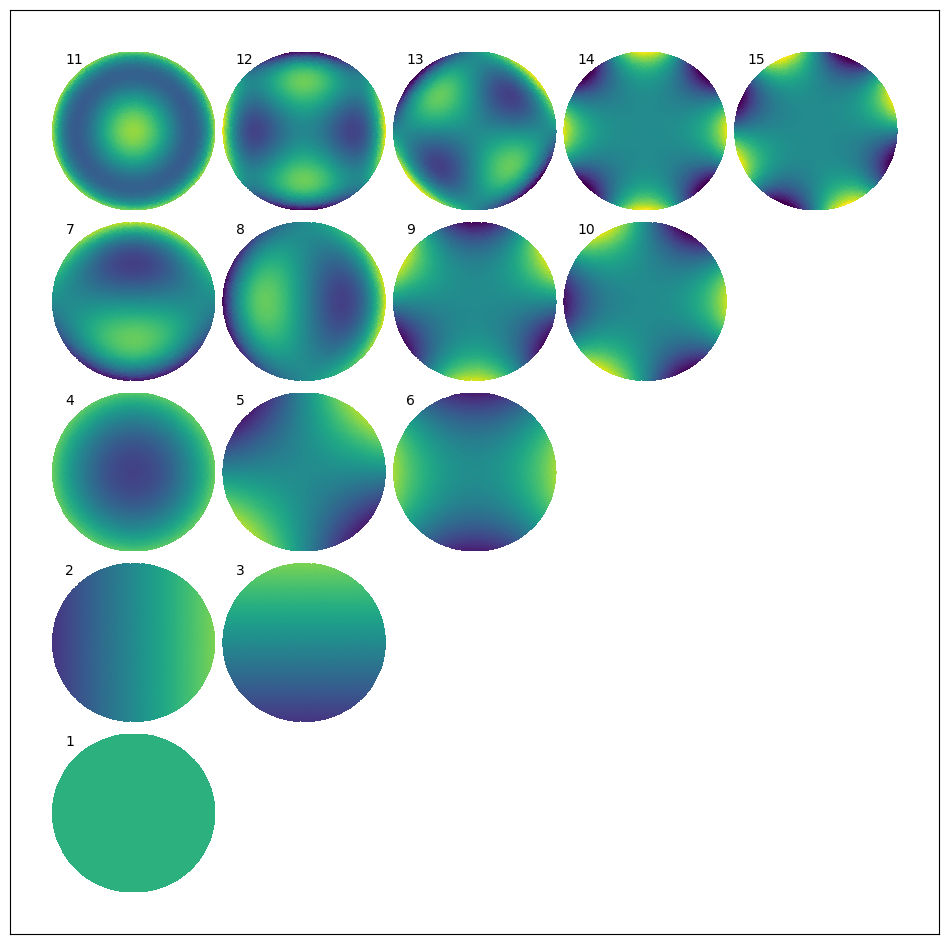

In [52]:
fig, ax =plt.subplots(figsize=(12,12))
vmin = np.min(modes[7,:])
vmax = np.max(modes[7,:])
l = 1
k = 0
for i in range(6):
    for j in range(i):
        xo = j*l
        yo = i*l

        x = xy[:,0]
        y = xy[:,1]
        #triang00 = tri.Triangulation(x,y)
        triang = tri.Triangulation(x+xo,y+yo)
        #triang.set_mask(np.hypot((x[triang.triangles]).mean(axis=1),
        #            (y[triang.triangles]).mean(axis=1))
        #< 0.21)
        h = ax.tripcolor(triang,modes[:,k],vmin=vmin,vmax=vmax)

        k+=1

        ax.text(xo-0.8*l/2,yo+0.8*l/2,f"{k}")
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])

#fig.colorbar(h,ax=ax)

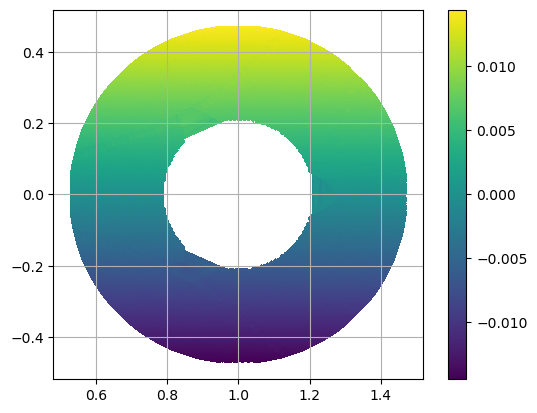

In [23]:
fig, ax =plt.subplots()
x = xy[:,0]
y = xy[:,1]
triang = tri.Triangulation(x+1,y)
triang.set_mask(np.hypot((x[triang.triangles]).mean(axis=1),
            (y[triang.triangles]).mean(axis=1))
< 0.21)
h = ax.tripcolor(triang,modes[:,2])
ax.set_aspect("equal")
fig.colorbar(h,ax=ax)
ax.grid()

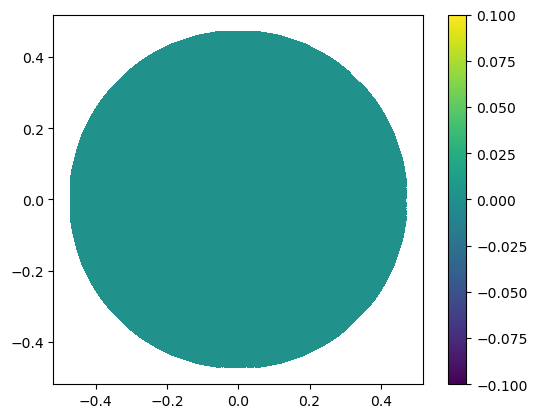

In [13]:
fig, ax =plt.subplots()
h = ax.tripcolor(xy[:,0],xy[:,1],opd)
ax.set_aspect("equal")
fig.colorbar(h,ax=ax)

In [14]:
c[:4]

array([ 4.78937963e+01, -1.91241884e+01,  2.44173382e+03, -6.37260068e-01])

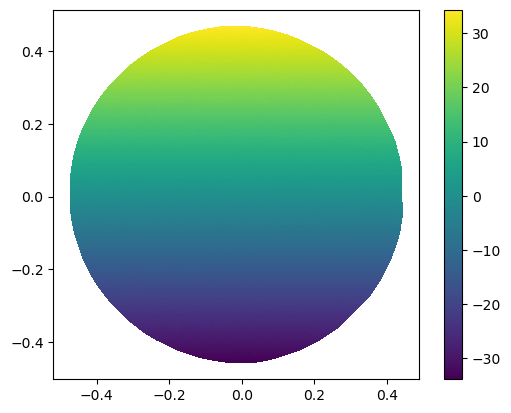

In [13]:
q = modes[:,:4]@c[:4]
fig, ax =plt.subplots()
h = ax.tripcolor(xy[:,0],xy[:,1],q)
ax.set_aspect("equal")
fig.colorbar(h,ax=ax)

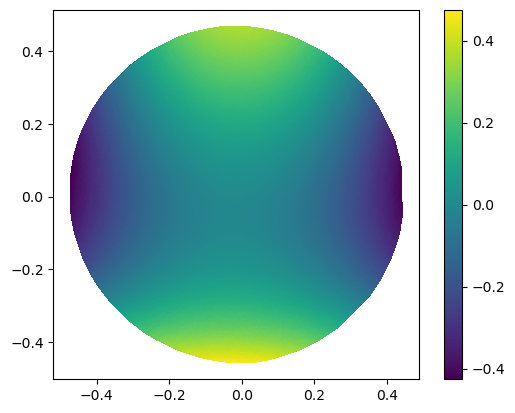

In [15]:
q = modes[:,4:]@c[4:]
fig, ax =plt.subplots()
h = ax.tripcolor(xy[:,0],xy[:,1],q)
ax.set_aspect("equal")
fig.colorbar(h,ax=ax)

In [10]:
whos

Variable   Type              Data/Info
--------------------------------------
ax         Axes              Axes(0.174298,0.11;0.570702x0.77)
c          ndarray           15: 15 elems, type `float64`, 120 bytes
fig        Figure            Figure(640x480)
h          PolyCollection    <matplotlib.collections.P<...>object at 0x7b81105e5850>
modes      ndarray           15x20444: 306660 elems, type `float64`, 2453280 bytes (2.339630126953125 Mb)
np         module            <module 'numpy' from '/ho<...>kages/numpy/__init__.py'>
opd        ndarray           20444: 20444 elems, type `float64`, 163552 bytes (159.71875 kb)
plt        module            <module 'matplotlib.pyplo<...>es/matplotlib/pyplot.py'>
tri        module            <module 'matplotlib.tri' <...>plotlib/tri/__init__.py'>
xy         ndarray           20444x2: 40888 elems, type `float64`, 327104 bytes (319.4375 kb)
zernp      dict              n=3
